# Backbone Extraction - Disparity Filter

Five-stage pipeline:

1. **Alpha sensitivity** on the annual graph
2. **Annual backbone** via the Disparity Filter at the chosen α
3. **Seasonal diagnostics** - checks on the raw seasonal networks induced on the backbone
4. **Seasonal strategy selection** 
5. **Saving** all seasonal layers with the chosen strategy

Reference: Serrano, Boguñá & Vespignani (2009), *PNAS*.

In [1]:
# ── Repository root ───────────────────────────────────────────────────────────

from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name in ('notebooks', 'legacy') else Path.cwd()
assert (ROOT / 'data').is_dir(), f'Repository root not found from {Path.cwd()}'

## 0 — Parameters

**`ALPHAS`**

**`SEASONAL_STRATEGY`**.  
- `'induced'` → subgraph induced on the annual backbone nodes, no Disparity Filter on the seasonal networks   
- `'backbone'` → independent Disparity Filter on each seasonal network with `ALPHA_SEASONAL`  
- `'induced_backbone'` → first induce on the annual backbone, then apply the Disparity Filter to the induced layer

In [2]:
# ── Parametri per il backbone ─────────────────────────────────────────────────
ALPHA = 0.05             # α per il backbone annuale

SEASONAL_STRATEGY = 'induced'   
ALPHA_SEASONAL    = 0.10        

# ── Percorsi e costanti ───────────────────────────────────────────────────────
WEIGHT       = 'weight'
NETWORKS_DIR = ROOT / 'data' / 'networks'
FIGURES_DIR  = ROOT / 'figures'
FIG_DPI      = 300

SEASONS      = ['winter_0', 'spring', 'summer', 'autumn', 'winter_1']
SEASON_NAMES = {
    'winter_0': 'Winter\u2080', 'spring': 'Spring', 'summer': 'Summer',
    'autumn': 'Autumn', 'winter_1': 'Winter\u2081',
}
ALL_NETWORKS   = ['annual'] + SEASONS
NETWORK_LABELS = {'annual': 'Annual (2025)', **SEASON_NAMES}

import os
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(NETWORKS_DIR, exist_ok=True)
print('Parameters set.')
print(f'  ALPHA              = {ALPHA}')
print(f'  SEASONAL_STRATEGY  = {SEASONAL_STRATEGY!r}')
print(f'  ALPHA_SEASONAL     = {ALPHA_SEASONAL}')

Parameters set.
  ALPHA              = 0.05
  SEASONAL_STRATEGY  = 'induced'
  ALPHA_SEASONAL     = 0.1


## 1 - Imports

In [ ]:
import json
import warnings
warnings.filterwarnings('ignore')

import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='ticks', context='paper', font_scale=1.1, rc={
    'font.family': 'serif', 'axes.linewidth': 0.7,
    'grid.linewidth': 0.4, 'grid.alpha': 0.3,
})

SEASON_PAL = {
    'annual': '#333333', 'winter_0': '#5B8EB8', 'spring': '#7FB069',
    'summer': '#E0A040', 'autumn': '#C7563C', 'winter_1': '#5B8EB8',
}


def disparity_filter(G, weight='weight', alpha=0.05):
    """Disparity Filter (Serrano et al. 2009).
    Keeps (u,v) if significant for at least one endpoint.
    Degree-1 nodes always keep their edge.
    """
    strength = {u: sum(d.get(weight, 1) for _, _, d in G.edges(u, data=True))
                for u in G.nodes()}
    degree = dict(G.degree())
    kept = []
    for u, v, data in G.edges(data=True):
        w  = data.get(weight, 1)
        ku, kv = degree[u], degree[v]
        su, sv = strength[u], strength[v]
        sig_u = (1 - w / su) ** (ku - 1) if ku > 1 and su > 0 else 1.0
        sig_v = (1 - w / sv) ** (kv - 1) if kv > 1 and sv > 0 else 1.0
        if min(sig_u, sig_v) < alpha or ku == 1 or kv == 1:
            kept.append((u, v))
    return G.edge_subgraph(kept).copy()


def net_stats(G, weight='weight'):
    if G.number_of_nodes() == 0:
        return dict(nodes=0, edges=0, density=0, components=0,
                    gcc_nodes=0, gcc_pct=0, total_weight=0)
    ccs = list(nx.connected_components(G))
    gcc = max(ccs, key=len)
    tw  = sum(d.get(weight, 1) for _, _, d in G.edges(data=True))
    return dict(
        nodes=G.number_of_nodes(), edges=G.number_of_edges(),
        density=nx.density(G), components=len(ccs),
        gcc_nodes=len(gcc), gcc_pct=len(gcc) / G.number_of_nodes(),
        total_weight=tw,
    )


def load_network(name):
    path = NETWORKS_DIR / f'{name}.graphml.gz'
    G = nx.read_graphml(path)
    try:
        G = nx.relabel_nodes(G, {n: int(n) for n in G.nodes()})
    except (ValueError, TypeError):
        pass
    return G


def recompute_jaccard(G):
    for u, v, data in G.edges(data=True):
        nu = set(G.neighbors(u))
        nv = set(G.neighbors(v))
        inter = len(nu & nv)
        union = len(nu | nv)
        data['jaccard'] = inter / union if union > 0 else 0.0
    return G


def savefig(fig, name):
    fig.savefig(f'{FIGURES_DIR}/{name}.png', dpi=FIG_DPI, bbox_inches='tight', pad_inches=0.05)
    fig.savefig(f'{FIGURES_DIR}/{name}.pdf', bbox_inches='tight', pad_inches=0.05)
    print(f'  💾 {FIGURES_DIR}/{name}.png + .pdf')


print('Functions loaded.')

Functions loaded.


## 2 - Alpha sensitivity (annual network)

In [3]:
alphas_test = [0.001, 0.005, 0.01, 0.02, 0.05, 0.10, 0.20, 0.50]

print('Loading annual network...')
G_annual_raw = load_network('annual')
orig = net_stats(G_annual_raw, WEIGHT)
print(f'  Annual: {orig["nodes"]:,} nodes | {orig["edges"]:,} edges | '
      f'density={orig["density"]:.5f} | GCC={orig["gcc_pct"]*100:.1f}%\n')

rows = []
for a in alphas_test:
    B = disparity_filter(G_annual_raw, weight=WEIGHT, alpha=a)
    s = net_stats(B, WEIGHT)
    rows.append({
        'alpha':    a,
        'Nodes':    s['nodes'],
        'Nodes %':  round(s['nodes'] / orig['nodes'] * 100, 1),
        'Edges':    s['edges'],
        'Edges %':  round(s['edges'] / orig['edges'] * 100, 1),
        'Weight %': round(s['total_weight'] / orig['total_weight'] * 100, 1),
        'Density':  round(s['density'], 5),
        'GCC %':    round(s['gcc_pct'] * 100, 1),
        'Comp.':    s['components'],
    })

df_alpha = pd.DataFrame(rows).set_index('alpha')
print(df_alpha.to_string())
print(f'\n→ ALPHA corrente = {ALPHA}:  '
      f'{df_alpha.loc[ALPHA, "Edges %"]:.1f}% edges,  '
      f'{df_alpha.loc[ALPHA, "GCC %"]:.1f}% GCC')

Loading annual network...
  Annual: 6,977 nodes | 1,783,415 edges | density=0.07328 | GCC=100.0%

       Nodes  Nodes %    Edges  Edges %  Weight %  Density  GCC %  Comp.
alpha                                                                   
0.001   1073     15.4    19383      1.1      16.9  0.03370   97.8     13
0.005   1543     22.1    39299      2.2      24.9  0.03303   98.7     11
0.010   1872     26.8    54729      3.1      29.5  0.03125   99.0     10
0.020   2286     32.8    78275      4.4      34.9  0.02997   99.3      9
0.050   3023     43.3   134305      7.5      44.2  0.02940   99.5      8
0.100   3877     55.6   218052     12.2      53.6  0.02902   99.7      7
0.200   5115     73.3   395284     22.2      65.9  0.03022   99.9      4
0.500   6945     99.5  1279813     71.8      91.5  0.05308  100.0      2

→ ALPHA corrente = 0.05:  7.5% edges,  99.5% GCC


  💾 figures/backbone_alpha_sensitivity_annual.png + .pdf


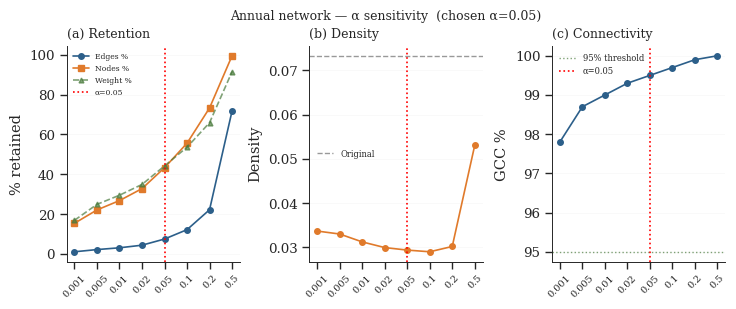

In [4]:
# ── Sensitivity plot ──────────────────────────────────────────────────────────
x        = np.arange(len(alphas_test))
xlabels  = [str(a) for a in alphas_test]
chosen_i = alphas_test.index(ALPHA)

fig, axes = plt.subplots(1, 3, figsize=(8.5, 2.8), gridspec_kw={'wspace': 0.40})

# (a) Retention
ax = axes[0]
ax.plot(x, df_alpha['Edges %'],  'o-', color='#2C5F8A', ms=4, label='Edges %')
ax.plot(x, df_alpha['Nodes %'],  's-', color='#E07A2B', ms=4, label='Nodes %')
ax.plot(x, df_alpha['Weight %'], '^--', color='#4A7B3D', ms=3.5, alpha=0.7, label='Weight %')
ax.axvline(chosen_i, color='red', ls=':', lw=1.2, label=f'α={ALPHA}')
ax.set_xticks(x); ax.set_xticklabels(xlabels, rotation=45, fontsize=7)
ax.set_ylabel('% retained'); ax.set_title('(a) Retention', loc='left', fontsize=9)
ax.legend(fontsize=5.5, frameon=False); ax.grid(axis='y', alpha=0.2)

# (b) Density
ax = axes[1]
ax.plot(x, df_alpha['Density'], 'o-', color='#E07A2B', ms=4)
ax.axhline(orig['density'], color='#999', ls='--', lw=1, label='Original')
ax.axvline(chosen_i, color='red', ls=':', lw=1.2)
ax.set_xticks(x); ax.set_xticklabels(xlabels, rotation=45, fontsize=7)
ax.set_ylabel('Density'); ax.set_title('(b) Density', loc='left', fontsize=9)
ax.legend(fontsize=6, frameon=False); ax.grid(axis='y', alpha=0.2)

# (c) GCC%
ax = axes[2]
ax.plot(x, df_alpha['GCC %'], 'o-', color='#2C5F8A', ms=4)
ax.axhline(95, color='#4A7B3D', ls=':', lw=1, alpha=0.7, label='95% threshold')
ax.axvline(chosen_i, color='red', ls=':', lw=1.2, label=f'α={ALPHA}')
ax.set_xticks(x); ax.set_xticklabels(xlabels, rotation=45, fontsize=7)
ax.set_ylabel('GCC %'); ax.set_title('(c) Connectivity', loc='left', fontsize=9)
ax.legend(fontsize=6, frameon=False); ax.grid(axis='y', alpha=0.2)

sns.despine()
fig.suptitle(f'Annual network — α sensitivity  (chosen α={ALPHA})', fontsize=9, y=1.01)
fig.tight_layout()
savefig(fig, 'backbone_alpha_sensitivity_annual')
plt.show()

## 3  Annual backbone

In [5]:
ALPHA = 0.05

print(f'Building annual backbone (α={ALPHA})...')
B_annual = disparity_filter(G_annual_raw, weight=WEIGHT, alpha=ALPHA)
s_orig   = net_stats(G_annual_raw, WEIGHT)
s_back   = net_stats(B_annual,     WEIGHT)

print(f'  Original : {s_orig["nodes"]:>6,} nodes | {s_orig["edges"]:>9,} edges | density={s_orig["density"]:.5f}')
print(f'  Backbone : {s_back["nodes"]:>6,} nodes ({100*s_back["nodes"]/s_orig["nodes"]:.1f}%) | '
      f'{s_back["edges"]:>9,} edges ({100*s_back["edges"]/s_orig["edges"]:.1f}%) | '
      f'density={s_back["density"]:.5f}')
print(f'  GCC      : {s_back["gcc_pct"]*100:.1f}% | components: {s_back["components"]}')

# GCC subgraph
gcc_nodes    = max(nx.connected_components(B_annual), key=len)
B_annual_gcc = B_annual.subgraph(gcc_nodes).copy()
BACKBONE_NODES = set(B_annual_gcc.nodes())   # nodi GCC del backbone annuale
print(f'  GCC nodes: {len(BACKBONE_NODES):,}  (usati come riferimento per i layer stagionali)')

# Salva
out_path = NETWORKS_DIR / 'annual_backbone.graphml.gz'
nx.write_graphml(B_annual, out_path)
print(f'  Saved: {out_path}')

Building annual backbone (α=0.05)...
  Original :  6,977 nodes | 1,783,415 edges | density=0.07328
  Backbone :  3,023 nodes (43.3%) |   134,305 edges (7.5%) | density=0.02940
  GCC      : 99.5% | components: 8
  GCC nodes: 3,009  (usati come riferimento per i layer stagionali)
  Saved: data/networks\annual_backbone.graphml


## 4 — Seasonal networks

In [ ]:
print('Loading seasonal raw networks...')
graphs_raw = {}
for name in SEASONS:
    path = NETWORKS_DIR / f'{name}.graphml.gz'
    if os.path.exists(path):
        graphs_raw[name] = load_network(name)
        G = graphs_raw[name]
        print(f'  {SEASON_NAMES[name]:<12s}: {G.number_of_nodes():>5,} nodes | '
              f'{G.number_of_edges():>8,} edges | density={nx.density(G):.5f}')
    else:
        print(f'  WARNING: {path} not found')

# ── Induced layers ──────────────────────────────────────────────────
layers = {}
for name, G in graphs_raw.items():
    layer = G.subgraph(BACKBONE_NODES).copy()
    layer.add_nodes_from(BACKBONE_NODES - set(layer.nodes()))
    layers[name] = layer

print('\nLayer indotti costruiti.')

Loading seasonal raw networks...
  Winter₀     : 1,223 nodes |   44,966 edges | density=0.06018
  Spring      : 4,076 nodes |  491,800 edges | density=0.05922
  Summer      : 5,417 nodes |  962,476 edges | density=0.06561
  Autumn      : 3,230 nodes |  253,322 edges | density=0.04858
  Winter₁     : 1,268 nodes |   48,200 edges | density=0.06000

Layer indotti costruiti.


In [7]:
# ── CHECK 1: Node coverage ────────────────────────────────────────────────────
print('=' * 65)
print('CHECK 1 — Node coverage (backbone nodes presenti nella rete raw)')
print('=' * 65)
cov_rows = []
for name in SEASONS:
    if name not in graphs_raw: continue
    G = graphs_raw[name]
    present = BACKBONE_NODES & set(G.nodes())
    missing = BACKBONE_NODES - set(G.nodes())
    flag = ' ⚠️' if len(missing)/len(BACKBONE_NODES) > 0.40 else ''
    print(f'  {SEASON_NAMES[name]:<10s}: {len(present):4d} presenti  '
          f'{len(missing):4d} assenti  ({100*len(missing)/len(BACKBONE_NODES):.1f}%){flag}')
    cov_rows.append({'season': name, 'present': len(present), 'missing': len(missing),
                     'missing_pct': 100*len(missing)/len(BACKBONE_NODES)})

CHECK 1 — Node coverage (backbone nodes presenti nella rete raw)
  Winter₀   :  946 presenti  2063 assenti  (68.6%) ⚠️
  Spring    : 2371 presenti   638 assenti  (21.2%)
  Summer    : 2876 presenti   133 assenti  (4.4%)
  Autumn    : 2158 presenti   851 assenti  (28.3%)
  Winter₁   :  961 presenti  2048 assenti  (68.1%) ⚠️


In [ ]:
# ───────────────────────
print('=' * 65)
print('CHECK 2+3 — GCC% e isolati nei layer indotti')
print('=' * 65)
layer_stats = {}
for name in SEASONS:
    if name not in layers: continue
    L = layers[name]
    L_edges = L.subgraph([n for n, d in L.degree() if d > 0])
    ccs  = list(nx.connected_components(L_edges)) if L_edges.number_of_nodes() > 0 else []
    gcc_n = len(max(ccs, key=len)) if ccs else 0
    gcc_pct = 100 * gcc_n / len(BACKBONE_NODES)
    isolates = [n for n, d in L.degree() if d == 0]
    iso_pct  = 100 * len(isolates) / len(BACKBONE_NODES)
    flag2 = ' ⚠️' if gcc_pct < 80 else ''
    flag3 = ' ⚠️' if iso_pct > 30 else ''
    print(f'  {SEASON_NAMES[name]:<10s}: '
          f'edges={L.number_of_edges():6,}  '
          f'GCC={gcc_pct:5.1f}%{flag2}  '
          f'isolati={len(isolates):4d} ({iso_pct:.1f}%){flag3}')
    layer_stats[name] = dict(edges=L.number_of_edges(), gcc_pct=gcc_pct,
                              isolates=len(isolates), iso_pct=iso_pct)

CHECK 2+3 — GCC% e isolati nei layer indotti
  Winter₀   : edges=40,757  GCC= 31.4% ⚠️  isolati=2065 (68.6%) ⚠️
  Spring    : edges=403,217  GCC= 78.8% ⚠️  isolati= 639 (21.2%)
  Summer    : edges=782,126  GCC= 95.6%  isolati= 133 (4.4%)
  Autumn    : edges=223,590  GCC= 71.7% ⚠️  isolati= 852 (28.3%)
  Winter₁   : edges=43,119  GCC= 31.9% ⚠️  isolati=2050 (68.1%) ⚠️


In [ ]:
# ── CHECK 4: Edge weight distribution ────────────────────────────────────────
print('=' * 65)
print('CHECK 4 — Edge weight distribution nei layer indotti')
print('=' * 65)
weight_totals = {}
for name in SEASONS:
    if name not in layers: continue
    L = layers[name]
    ws = [d.get(WEIGHT, 1) for _, _, d in L.edges(data=True)]
    if not ws:
        print(f'  {SEASON_NAMES[name]:<10s}: no edges')
        weight_totals[name] = 0
        continue
    ws = np.array(ws)
    singleton_pct = 100 * (ws == 1).sum() / len(ws)
    flag = ' ⚠️' if np.median(ws) <= 1 else ''
    print(f'  {SEASON_NAMES[name]:<10s}: '
          f'n={len(ws):6,}  mean={ws.mean():.1f}  '
          f'median={np.median(ws):.0f}  max={ws.max():.0f}  '
          f'singleton={singleton_pct:.1f}%{flag}')
    weight_totals[name] = ws.sum()

# CHECK 7: outliers
print()
print('CHECK 7 — Peso totale per stagione (verifica outlier >5× la media)')
vals = np.array(list(weight_totals.values()))
mean_w = vals.mean() if len(vals) else 1
for name, tot in weight_totals.items():
    flag = ' ⚠️' if tot > 5 * mean_w else ''
    print(f'  {SEASON_NAMES[name]:<10s}: {tot:>12,.0f}{flag}')
print(f'  Media: {mean_w:>12,.0f}')

CHECK 4 — Edge weight distribution nei layer indotti
  Winter₀   : n=40,757  mean=6.2  median=3  max=196  singleton=0.0%
  Spring    : n=403,217  mean=6.4  median=3  max=301  singleton=0.0%
  Summer    : n=782,126  mean=6.7  median=4  max=375  singleton=0.0%
  Autumn    : n=223,590  mean=5.3  median=3  max=195  singleton=0.0%
  Winter₁   : n=43,119  mean=7.0  median=3  max=210  singleton=0.0%

CHECK 7 — Peso totale per stagione (verifica outlier >5× la media)
  Winter₀   :      251,072
  Spring    :    2,565,117
  Summer    :    5,230,252
  Autumn    :    1,187,967
  Winter₁   :      300,430
  Media:    1,906,968


In [ ]:
# ── CHECK 5: Edge overlap between ajacent seasons ──────────────────────────────
print('=' * 65)
print('CHECK 5')
print('=' * 65)
seasons_ord = [s for s in SEASONS if s in layers]
for i in range(len(seasons_ord) - 1):
    s1, s2 = seasons_ord[i], seasons_ord[i+1]
    e1 = {(min(u,v), max(u,v)) for u,v in layers[s1].edges()}
    e2 = {(min(u,v), max(u,v)) for u,v in layers[s2].edges()}
    union = e1 | e2
    jac = len(e1 & e2) / len(union) if union else 0
    flag = ' ⚠️' if jac < 0.05 else ''
    print(f'  {SEASON_NAMES[s1]:<10s} ↔ {SEASON_NAMES[s2]:<10s}: '
          f'{len(e1&e2):5d} edge condivisi | Jaccard={jac:.3f}{flag}')

CHECK 5 — Edge Jaccard tra stagioni adiacenti
  Winter₀    ↔ Spring    : 30985 edge condivisi | Jaccard=0.075
  Spring     ↔ Summer    : 215218 edge condivisi | Jaccard=0.222
  Summer     ↔ Autumn    : 150545 edge condivisi | Jaccard=0.176
  Autumn     ↔ Winter₁   : 31031 edge condivisi | Jaccard=0.132


In [ ]:
# ── CHECK 6: Jaccard comparison ─────────────────────
print('=' * 65)
print('CHECK 6: Jaccard comparison')
print('=' * 65)
for name in SEASONS:
    if name not in layers: continue
    L = layers[name].copy()
    orig_jac = [d.get('jaccard', np.nan) for _, _, d in L.edges(data=True)]
    orig_jac = [v for v in orig_jac if not np.isnan(v)]
    if not orig_jac:
        print(f'  {SEASON_NAMES[name]:<10s}: no jaccard attribute found')
        continue
    L_new = recompute_jaccard(L)
    new_jac = [d['jaccard'] for _, _, d in L_new.edges(data=True)]
    delta = np.mean(new_jac) - np.mean(orig_jac)
    print(f'  {SEASON_NAMES[name]:<10s}: '
          f'mean jac originale={np.mean(orig_jac):.4f}  '
          f'ricalcolato={np.mean(new_jac):.4f}  '
          f'delta={delta:+.4f}')

In [ ]:
# ── Heatmap ──────────────────────────────────────────
diag_data = {
    'GCC %':       [layer_stats.get(s, {}).get('gcc_pct', 0)   for s in SEASONS if s in layer_stats],
    'Isolati %':   [layer_stats.get(s, {}).get('iso_pct', 0)   for s in SEASONS if s in layer_stats],
    'Miss. nodes%':[v['missing_pct'] for v in cov_rows],
}
season_labels = [SEASON_NAMES[s] for s in SEASONS if s in layer_stats]
df_diag = pd.DataFrame(diag_data, index=season_labels)

fig, axes = plt.subplots(1, 3, figsize=(9, 2.5), gridspec_kw={'wspace': 0.5})

cmaps   = ['RdYlGn', 'RdYlGn_r', 'RdYlGn_r']
vmins   = [50, 0, 0]
vmaxs   = [100, 50, 50]
titles  = ['(a) GCC %\n(higher = better)', '(b) Isolati %\n(lower = better)',
           '(c) Missing nodes %\n(lower = better)']

for ax, col, cmap, vmin, vmax, title in zip(axes, df_diag.columns, cmaps, vmins, vmaxs, titles):
    vals = df_diag[col].values.reshape(-1, 1)
    im = ax.imshow(vals, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
    ax.set_yticks(range(len(season_labels)))
    ax.set_yticklabels(season_labels, fontsize=8)
    ax.set_xticks([])
    ax.set_title(title, fontsize=8, loc='left')
    plt.colorbar(im, ax=ax, shrink=0.8)
    for i, v in enumerate(df_diag[col].values):
        ax.text(0, i, f'{v:.1f}', ha='center', va='center', fontsize=8)

fig.suptitle('Diagnostica layer stagionali indotti su backbone annuale', fontsize=9, y=1.02)
fig.tight_layout()
savefig(fig, 'backbone_seasonal_diagnostics')
plt.show()

print()

## 5 — Apply the seasonal strategy and save


In [ ]:
# ── Sensitivity sweep on induced layers ───────────────────
SWEEP_SEASONS = ['spring', 'summer']
alphas_sweep  = [0.001, 0.005, 0.01, 0.02, 0.05, 0.10, 0.20, 0.30, 0.40, 0.50]

for name in SWEEP_SEASONS:
    G_raw  = graphs_raw[name]
    label  = SEASON_NAMES[name]

    L_ind = G_raw.subgraph(BACKBONE_NODES).copy()
    orig  = net_stats(L_ind, WEIGHT)

    present_nodes = set(L_ind.nodes())   
    n_present     = len(present_nodes)
    ceiling_pct   = 100 * n_present / len(BACKBONE_NODES)

    print(f'\n{label} — layer indotto su backbone nodes:')
    print(f'  Nodi presenti : {n_present:,} / {len(BACKBONE_NODES):,} '
          f'({ceiling_pct:.1f}% — ceiling strutturale)')
    print(f'  Edge          : {orig["edges"]:,} | density={orig["density"]:.5f}')
    print(f'  Nota: il restante {100-ceiling_pct:.1f}% sono specie assenti in {label} '
          f'→ isolati a qualsiasi alpha, non contano per GCC\n')

    print(f'  {"alpha":>6}  {"Nodes%":>8}  {"Edges%":>8}  '
          f'{"GCC%/tot":>9}  {"GCC%/pres":>10}  {"Comp.":>6}  {"Density":>9}')
    print('  ' + '-' * 68)

    for a in alphas_sweep:
        B = disparity_filter(L_ind, weight=WEIGHT, alpha=a)
        s = net_stats(B, WEIGHT)

        # GCC tra i nodi con almeno un edge dopo il filtro
        ccs   = list(nx.connected_components(B)) if B.number_of_nodes() > 0 else []
        gcc_n = len(max(ccs, key=len)) if ccs else 0

        
        # GCC% su tutti i backbone nodes  → confronto cross-stagionale
        # GCC% sui soli nodi presenti → qualità del filtro, corretta per assenze biologiche
        gcc_pct_tot  = 100 * gcc_n / len(BACKBONE_NODES)
        gcc_pct_pres = 100 * gcc_n / n_present if n_present > 0 else 0

        n_pct = 100 * s['nodes'] / n_present if n_present else 0
        e_pct = 100 * s['edges'] / orig['edges'] if orig['edges'] else 0

        # Flag su GCC%/presenti — quella che conta per la qualità del backbone
        flag = ' ⚠️' if gcc_pct_pres < 90 else ''

        print(f'  {a:>6.3f}  {n_pct:>8.1f}  {e_pct:>8.1f}  '
              f'{gcc_pct_tot:>9.1f}  {gcc_pct_pres:>10.1f}  '
              f'{s["components"]:>6}  {s["density"]:>9.5f}{flag}')

print('\n>>> Scegli alpha per Spring e Summer guardando GCC%/pres ≥ 90%.')
print('    GCC%/tot serve solo per confrontare i layer tra stagioni nel report.')


Spring — layer indotto su backbone nodes:
  Nodi presenti : 2,371 / 3,009 (78.8% — ceiling strutturale)
  Edge          : 403,217 | density=0.14351
  Nota: il restante 21.2% sono specie assenti in Spring → isolati a qualsiasi alpha, non contano per GCC

   alpha    Nodes%    Edges%   GCC%/tot   GCC%/pres   Comp.    Density
  --------------------------------------------------------------------
   0.001      14.0       0.5       10.6        13.4       8    0.03786 ⚠️
   0.005      22.1       1.3       17.2        21.8       4    0.03821 ⚠️
   0.010      27.6       2.0       21.8        27.6       1    0.03834 ⚠️
   0.020      36.0       3.2       28.4        36.0       1    0.03590 ⚠️
   0.050      52.0       6.4       41.0        52.0       1    0.03415 ⚠️
   0.100      66.8      11.5       52.7        66.8       1    0.03689 ⚠️
   0.200      84.6      22.5       66.7        84.6       1    0.04516 ⚠️
   0.300      92.9      35.8       73.2        92.9       1    0.05961
   0.400      

In [ ]:
SEASON_CONFIG = {
    'winter_0': {'strategy': 'induced',          'alpha': None},
    'spring':   {'strategy': 'induced_backbone', 'alpha': 0.30},
    'summer':   {'strategy': 'induced_backbone', 'alpha': 0.20},
    'autumn':   {'strategy': 'induced',          'alpha': None},
    'winter_1': {'strategy': 'induced',          'alpha': None},
}

print(f'Backbone reference nodes: {len(BACKBONE_NODES):,}\n')
print(f'  {"Season":<10} {"Strategy":<20} {"Alpha"}')
print('  ' + '-' * 38)
for name, cfg in SEASON_CONFIG.items():
    print(f'  {SEASON_NAMES[name]:<10} {cfg["strategy"]:<20} {cfg["alpha"] or "—"}')
print()

summary_seasonal = {}

for name in SEASONS:
    if name not in graphs_raw:
        print(f'WARNING: {name} not found, skipping')
        continue

    G_raw    = graphs_raw[name]
    label    = SEASON_NAMES[name]
    strategy = SEASON_CONFIG[name]['strategy']
    alpha    = SEASON_CONFIG[name]['alpha']

    print(f'── {label} ({strategy}, α={alpha or "—"}) {"─" * max(1, 38-len(label)-len(strategy))}')

    #  ────────────────────────────────────────────
    if strategy == 'induced':
        L = G_raw.subgraph(BACKBONE_NODES).copy()
        L.add_nodes_from(BACKBONE_NODES - set(L.nodes()))
        L = recompute_jaccard(L)

    elif strategy == 'induced_backbone':
        assert alpha is not None, f'alpha richiesto per induced_backbone ({name})'
        
        L_ind = G_raw.subgraph(BACKBONE_NODES).copy()
        L = disparity_filter(L_ind, weight=WEIGHT, alpha=alpha)
        
        L.add_nodes_from(BACKBONE_NODES - set(L.nodes()))
        L = recompute_jaccard(L)

    elif strategy == 'backbone':
        assert alpha is not None, f'alpha richiesto per backbone ({name})'
        L = disparity_filter(G_raw, weight=WEIGHT, alpha=alpha)
        L.add_nodes_from(BACKBONE_NODES - set(L.nodes()))
        L = recompute_jaccard(L)

    else:
        raise ValueError(f'Strategy non valida per {name}: {strategy!r}')

    # ── Stats ─────────────────────────────────────────────────────────────────
    s_raw        = net_stats(G_raw, WEIGHT)
    present_nodes = BACKBONE_NODES & set(graphs_raw[name].nodes())
    n_present     = len(present_nodes)

    L_conn  = L.subgraph([n for n, d in L.degree() if d > 0])
    ccs     = list(nx.connected_components(L_conn)) if L_conn.number_of_nodes() > 0 else []
    gcc_n   = len(max(ccs, key=len)) if ccs else 0

    gcc_pct_tot  = 100 * gcc_n / len(BACKBONE_NODES)
    gcc_pct_pres = 100 * gcc_n / n_present if n_present > 0 else 0
    isolates     = sum(1 for _, d in L.degree() if d == 0)
    e_pct        = 100 * L.number_of_edges() / s_raw['edges'] if s_raw['edges'] else 0

    print(f'  Raw    : {s_raw["nodes"]:>5,} nodes | {s_raw["edges"]:>8,} edges')
    print(f'  Layer  : {L.number_of_nodes():>5,} nodes | {L.number_of_edges():>8,} edges '
          f'({e_pct:.1f}% of raw)')
    print(f'  GCC    : {gcc_pct_tot:.1f}% of backbone | '
          f'{gcc_pct_pres:.1f}% of present | '
          f'isolati={isolates} ({100*isolates/len(BACKBONE_NODES):.1f}%)')

    # ── Save graphml + edgelist ──────────────────────────────────────────────
    out_graphml = NETWORKS_DIR / f'{name}_layer.graphml.gz'
    out_csv     = NETWORKS_DIR / f'{name}_layer.edgelist.csv.gz'
    nx.write_graphml(L, out_graphml)
    edges = [(u, v, d.get('weight'), d.get('jaccard'), d.get('simpson'), d.get('pmi'))
             for u, v, d in L.edges(data=True)]
    pd.DataFrame(edges, columns=['source', 'target', 'weight', 'jaccard', 'simpson', 'pmi']
                ).to_csv(out_csv, index=False)
    print(f'  Saved  : {out_graphml}')

    summary_seasonal[name] = dict(
        strategy=strategy, alpha=alpha,
        raw_nodes=s_raw['nodes'], raw_edges=s_raw['edges'],
        layer_nodes=L.number_of_nodes(), layer_edges=L.number_of_edges(),
        edge_pct=round(e_pct, 2),
        gcc_pct_tot=round(gcc_pct_tot, 1),
        gcc_pct_pres=round(gcc_pct_pres, 1),
        isolates=isolates,
    )
    print()

print('✅ Layer stagionali salvati.')

Backbone reference nodes: 3,009

  Season     Strategy             Alpha
  --------------------------------------
  Winter₀    induced              —
  Spring     induced_backbone     0.3
  Summer     induced_backbone     0.2
  Autumn     induced              —
  Winter₁    induced              —

── Winter₀ (induced, α=—) ────────────────────────
  Raw    : 1,223 nodes |   44,966 edges
  Layer  : 3,009 nodes |   40,757 edges (90.6% of raw)
  GCC    : 31.4% of backbone | 99.8% of present | isolati=2065 (68.6%)
  Saved  : data/networks\winter_0_layer.graphml

── Spring (induced_backbone, α=0.3) ────────────────
  Raw    : 4,076 nodes |  491,800 edges
  Layer  : 3,009 nodes |  144,444 edges (29.4% of raw)
  GCC    : 73.2% of backbone | 92.9% of present | isolati=807 (26.8%)
  Saved  : data/networks\spring_layer.graphml

── Summer (induced_backbone, α=0.2) ────────────────
  Raw    : 5,417 nodes |  962,476 edges
  Layer  : 3,009 nodes |  178,998 edges (18.6% of raw)
  GCC    : 89.7% of ba

## 6 - Summary table

In [17]:
# ── Summary table annual ─────────────────────────────────────────────────────
print('Annual backbone:')
print(f'  α={ALPHA} | {s_back["nodes"]:,} nodes | {s_back["edges"]:,} edges | '
      f'GCC={s_back["gcc_pct"]*100:.1f}%\n')

# ── Summary table seasonal layers ────────────────────────────────────────────
rows = []
for name in SEASONS:
    if name not in summary_seasonal: continue
    s   = summary_seasonal[name]
    cfg = SEASON_CONFIG[name]
    rows.append({
        'Season':       SEASON_NAMES[name],
        'Strategy':     cfg['strategy'],
        'Alpha':        cfg['alpha'] or '—',
        'Raw edges':    s['raw_edges'],
        'Layer edges':  s['layer_edges'],
        'Edge %':       s['edge_pct'],
        'GCC%/tot':     s['gcc_pct_tot'],
        'GCC%/pres':    s['gcc_pct_pres'],
        'Isolates':     s['isolates'],
    })

df_summary = pd.DataFrame(rows).set_index('Season')
print('Seasonal layers:')
print(df_summary.to_string())

# ── Save JSON ─────────────────────────────────────────────────────────────────
full_summary = {
    'annual': dict(
        alpha=ALPHA,
        original=dict(nodes=s_orig['nodes'], edges=s_orig['edges'],
                      density=s_orig['density']),
        backbone=dict(nodes=s_back['nodes'], edges=s_back['edges'],
                      density=s_back['density'],
                      gcc_pct=round(s_back['gcc_pct']*100, 1)),
    ),
    'seasonal': summary_seasonal,
}
with open(NETWORKS_DIR / 'backbone_summary.json', 'w') as f:
    json.dump(full_summary, f, indent=2)
print('\n✅ backbone_summary.json saved.')


Annual backbone:
  α=0.05 | 3,023 nodes | 134,305 edges | GCC=99.5%

Seasonal layers:
                 Strategy Alpha  Raw edges  Layer edges  Edge %  GCC%/tot  GCC%/pres  Isolates
Season                                                                                        
Winter₀           induced     —      44966        40757   90.64      31.4       99.8      2065
Spring   induced_backbone   0.3     491800       144444   29.37      73.2       92.9       807
Summer   induced_backbone   0.2     962476       178998   18.60      89.7       93.8       311
Autumn            induced     —     253322       223590   88.26      71.7      100.0       852
Winter₁           induced     —      48200        43119   89.46      31.9       99.8      2050

✅ backbone_summary.json saved.


## 7 - Plots

  💾 figures/backbone_annual_reduction.png + .pdf


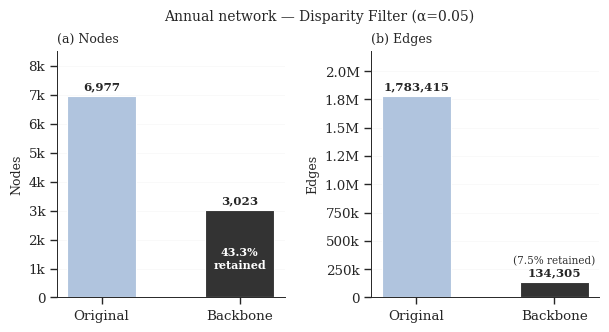

  💾 figures/backbone_degree_ccdf.png + .pdf


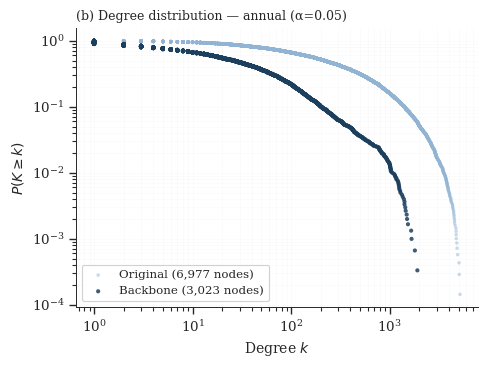

  💾 figures/backbone_seasonal_layers.png + .pdf


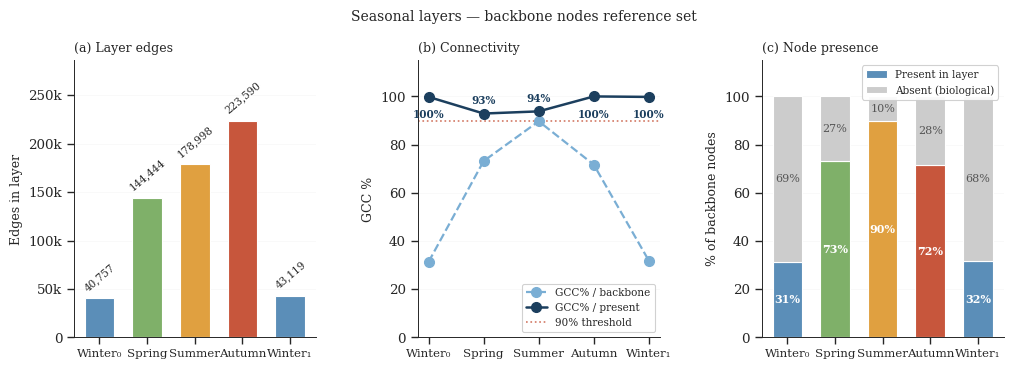

  💾 figures/backbone_seasonal_edge_jaccard.png + .pdf


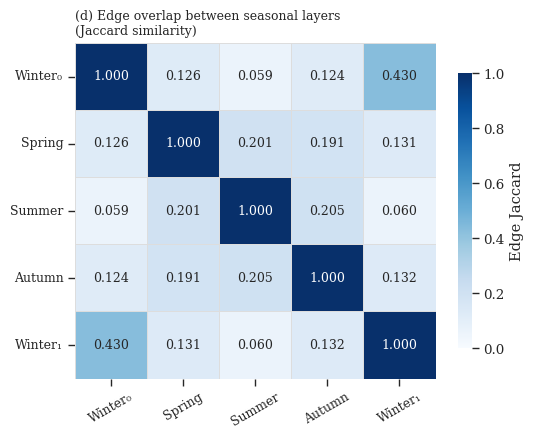

  💾 figures/backbone_taxon_presence_seasonal.png + .pdf


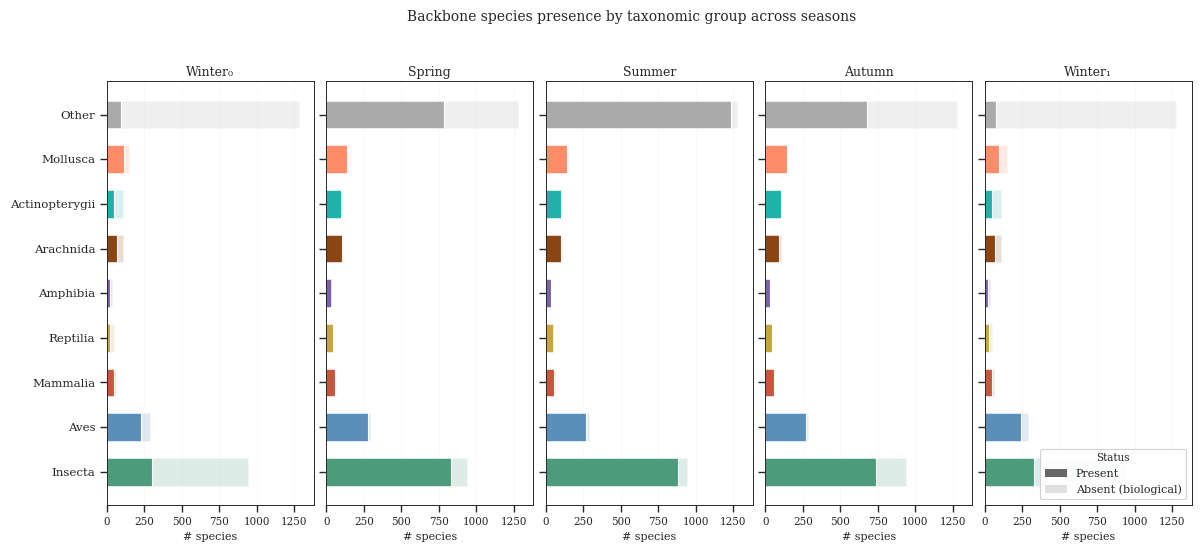

In [21]:
# ── Fig 1: Annual — Original vs Backbone ────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 3.2), gridspec_kw={'wspace': 0.38})

categories = ['Original', 'Backbone']
node_vals  = [s_orig['nodes'], s_back['nodes']]
edge_vals  = [s_orig['edges'], s_back['edges']]
colors     = ['#B0C4DE', '#333333']

for ax, vals, ylabel, title in [
    (ax1, node_vals, 'Nodes', '(a) Nodes'),
    (ax2, edge_vals, 'Edges', '(b) Edges'),
]:
    bars = ax.bar(categories, vals, color=colors, edgecolor='white', width=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                val + max(vals) * 0.02,
                f'{val:,}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
    ret_pct = 100 * vals[1] / vals[0]
    bar_h   = vals[1]
    if bar_h > max(vals) * 0.12:
        ax.text(1, bar_h * 0.45, f'{ret_pct:.1f}%\nretained',
                ha='center', va='center', fontsize=8, color='white', fontweight='bold')
    else:
        ax.text(1, bar_h + max(vals) * 0.08, f'({ret_pct:.1f}% retained)',
                ha='center', va='bottom', fontsize=7.5, color='#333333')
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, fontsize=9, loc='left')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda v, _: f'{v/1_000_000:.1f}M' if v >= 1e6
        else (f'{int(v/1000)}k' if v >= 1000 else f'{int(v)}')))
    ax.grid(axis='y', alpha=0.2)
    ax.set_ylim(0, max(vals) * 1.22)

fig.suptitle(f'Annual network — Disparity Filter (α={ALPHA})', fontsize=10, y=1.01)
sns.despine()
fig.tight_layout()
savefig(fig, 'backbone_annual_reduction')
plt.show()


# ── Fig 2: Degree distribution CCDF ─────────────────────────────────────────
B_annual_plot = nx.read_graphml(NETWORKS_DIR / 'annual_backbone.graphml.gz')
try:
    B_annual_plot = nx.relabel_nodes(B_annual_plot,
                                     {n: int(n) for n in B_annual_plot.nodes()})
except (ValueError, TypeError):
    pass

fig, ax = plt.subplots(figsize=(5, 3.8))

def plot_ccdf(G, label, color, ms, alpha_pt, zorder):
    degs = np.array(sorted([d for _, d in G.degree()], reverse=True))
    ccdf = np.arange(1, len(degs)+1) / len(degs)
    ax.scatter(degs, ccdf, s=ms**2, c=color, alpha=alpha_pt,
               edgecolors='none', zorder=zorder, label=label)

plot_ccdf(G_annual_raw,  f'Original ({G_annual_raw.number_of_nodes():,} nodes)',
          '#92B4D4', 2.5, 0.5, 2)
plot_ccdf(B_annual_plot, f'Backbone ({B_annual_plot.number_of_nodes():,} nodes)',
          '#1C3F5E', 3.0, 0.85, 3)

ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Degree $k$', fontsize=10)
ax.set_ylabel('$P(K \\geq k)$', fontsize=10)
ax.set_title(f'(b) Degree distribution — annual (α={ALPHA})', fontsize=9, loc='left')
ax.legend(frameon=True, fontsize=8.5, framealpha=0.9, edgecolor='#cccccc')
ax.grid(True, which='both', alpha=0.12)
sns.despine()
fig.tight_layout()
savefig(fig, 'backbone_degree_ccdf')
plt.show()


# ── Fig 3: Seasonal layers ───────────────────────────────────────────────────
seas_keys     = [s for s in SEASONS if s in summary_seasonal]
seas_labels   = [SEASON_NAMES[s] for s in seas_keys]
scolors       = [SEASON_PAL[s] for s in seas_keys]
layer_edges   = [summary_seasonal[s]['layer_edges']  for s in seas_keys]
gcc_tot_vals  = [summary_seasonal[s]['gcc_pct_tot']  for s in seas_keys]
gcc_pres_vals = [summary_seasonal[s]['gcc_pct_pres'] for s in seas_keys]
iso_pcts      = [100*summary_seasonal[s]['isolates']/len(BACKBONE_NODES) for s in seas_keys]
pres_pcts     = [100 - v for v in iso_pcts]

x   = np.arange(len(seas_keys))
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), gridspec_kw={'wspace': 0.42})

# (a) Edge count
ax = axes[0]
bars = ax.bar(x, layer_edges, color=scolors, edgecolor='white', width=0.62)
for bar, val in zip(bars, layer_edges):
    ax.text(bar.get_x() + bar.get_width()/2,
            val + max(layer_edges) * 0.025,
            f'{val:,}', ha='center', va='bottom', fontsize=7.5, rotation=40)
ax.set_xticks(x); ax.set_xticklabels(seas_labels, fontsize=8.5)
ax.set_ylabel('Edges in layer', fontsize=9)
ax.set_title('(a) Layer edges', fontsize=9, loc='left')
ax.set_ylim(0, max(layer_edges) * 1.28)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda v, _: f'{int(v/1000)}k' if v >= 1000 else f'{int(v)}'))
ax.grid(axis='y', alpha=0.2)

# (b) Connectivity — line plot invece di barre doppie
ax = axes[1]
ax.plot(x, gcc_tot_vals,  'o--', color='#7AAED4', lw=1.6, ms=7,
        label='GCC% / backbone', zorder=3)
ax.plot(x, gcc_pres_vals, 'o-',  color='#1C3F5E', lw=1.8, ms=7,
        label='GCC% / present',  zorder=4)
ax.axhline(90, color='#C7563C', ls=':', lw=1.2, alpha=0.8, label='90% threshold')
for xi, val in zip(x, gcc_pres_vals):
    offset = 3 if val < 96 else -5
    va     = 'bottom' if val < 96 else 'top'
    ax.text(xi, val + offset, f'{val:.0f}%', ha='center', va=va,
            fontsize=7.5, color='#1C3F5E', fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(seas_labels, fontsize=8.5)
ax.set_ylabel('GCC %', fontsize=9)
ax.set_ylim(0, 115)
ax.set_title('(b) Connectivity', fontsize=9, loc='left')
ax.legend(fontsize=7.5, frameon=True, framealpha=0.9,
          edgecolor='#cccccc', loc='lower right')
ax.grid(axis='y', alpha=0.2)

# (c) Node presence stacked bar
ax = axes[2]
ax.bar(x, pres_pcts, color=scolors, edgecolor='white', width=0.62,
       label='Present in layer')
ax.bar(x, iso_pcts, bottom=pres_pcts, color='#CCCCCC',
       edgecolor='white', width=0.62, label='Absent (biological)')
for i, (pv, iv) in enumerate(zip(pres_pcts, iso_pcts)):
    if pv > 8:
        ax.text(i, pv / 2, f'{pv:.0f}%', ha='center', va='center',
                fontsize=8, color='white', fontweight='bold')
    if iv > 8:
        ax.text(i, pv + iv / 2, f'{iv:.0f}%', ha='center', va='center',
                fontsize=8, color='#555555')
ax.set_xticks(x); ax.set_xticklabels(seas_labels, fontsize=8.5)
ax.set_ylabel('% of backbone nodes', fontsize=9)
ax.set_ylim(0, 115)
ax.set_title('(c) Node presence', fontsize=9, loc='left')
ax.legend(fontsize=7.5, frameon=True, framealpha=0.9,
          edgecolor='#cccccc', loc='upper right')
ax.grid(axis='y', alpha=0.2)

fig.suptitle('Seasonal layers — backbone nodes reference set', fontsize=10, y=1.02)
sns.despine()
fig.tight_layout()
savefig(fig, 'backbone_seasonal_layers')
plt.show()


# ── Fig 4: Edge Jaccard heatmap ──────────────────────────────────────────────
all_seasons = [s for s in SEASONS if s in summary_seasonal]

layer_edgesets = {}
for name in all_seasons:
    path = NETWORKS_DIR / f'{name}_layer.graphml.gz'
    if os.path.exists(path):
        L = nx.read_graphml(path)
        layer_edgesets[name] = {frozenset([u, v]) for u, v in L.edges()}

n_s     = len(all_seasons)
jac_mat = np.zeros((n_s, n_s))
for i, s1 in enumerate(all_seasons):
    for j, s2 in enumerate(all_seasons):
        e1, e2 = layer_edgesets.get(s1, set()), layer_edgesets.get(s2, set())
        union  = e1 | e2
        jac_mat[i, j] = len(e1 & e2) / len(union) if union else 0.0

slabels = [SEASON_NAMES[s] for s in all_seasons]
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(jac_mat, annot=True, fmt='.3f', cmap='Blues',
            xticklabels=slabels, yticklabels=slabels,
            vmin=0, vmax=1, linewidths=0.6, linecolor='#dddddd',
            annot_kws={'size': 9}, ax=ax,
            cbar_kws={'shrink': 0.82, 'label': 'Edge Jaccard'})
ax.set_title('(d) Edge overlap between seasonal layers\n(Jaccard similarity)',
             fontsize=9, loc='left')
ax.tick_params(axis='x', labelsize=9, rotation=30)
ax.tick_params(axis='y', labelsize=9, rotation=0)
fig.tight_layout()
savefig(fig, 'backbone_seasonal_edge_jaccard')
plt.show()


# ── Fig 5: Node presence by iconic_taxon ─────────────────────────────────────
SPECIES_PATH = ROOT / 'data' / 'raw' / 'species.csv.gz'

if os.path.exists(SPECIES_PATH):
    sp = pd.read_csv(SPECIES_PATH)
    INFORMATIVE_TAXA = {'Insecta','Aves','Reptilia','Amphibia',
                        'Mammalia','Arachnida','Actinopterygii','Mollusca'}
    sp['iconic_taxon'] = sp['iconic_taxon'].apply(
        lambda x: x if x in INFORMATIVE_TAXA else 'Other'
    )
    iconic_map_bb = sp.set_index('taxon_id')['iconic_taxon'].to_dict()

    ICONIC_PAL = {
        'Insecta': '#4C9B7A', 'Aves': '#5B8EB8', 'Reptilia': '#C7A540',
        'Amphibia': '#7B61A8', 'Mammalia': '#C7563C', 'Arachnida': '#8B4513',
        'Actinopterygii': '#20B2AA', 'Mollusca': '#FF8C69', 'Other': '#AAAAAA',
    }
    taxa_order = ['Insecta','Aves','Mammalia','Reptilia','Amphibia',
                  'Arachnida','Actinopterygii','Mollusca','Other']

    all_seasons = [s for s in SEASONS if s in summary_seasonal]
    n_seas      = len(all_seasons)

    season_data = {}
    for name in all_seasons:
        G_raw       = graphs_raw[name]
        present_set = BACKBONE_NODES & set(G_raw.nodes())
        absent_set  = BACKBONE_NODES - present_set
        pres = {t: 0 for t in taxa_order}
        abse = {t: 0 for t in taxa_order}
        for n in present_set:
            t = iconic_map_bb.get(n, 'Other')
            if t in pres: pres[t] += 1
        for n in absent_set:
            t = iconic_map_bb.get(n, 'Other')
            if t in abse: abse[t] += 1
        season_data[name] = {'present': pres, 'absent': abse}

    fig, axes = plt.subplots(1, n_seas, figsize=(2.8 * n_seas, 5.5),
                             sharey=True, gridspec_kw={'wspace': 0.06})
    if n_seas == 1: axes = [axes]

    y      = np.arange(len(taxa_order))
    height = 0.62

    for ax, name in zip(axes, all_seasons):
        pvals = np.array([season_data[name]['present'][t] for t in taxa_order], dtype=float)
        avals = np.array([season_data[name]['absent'][t]  for t in taxa_order], dtype=float)
        cols  = [ICONIC_PAL[t] for t in taxa_order]

        ax.barh(y, pvals, height=height, color=cols, edgecolor='white', linewidth=0.4)
        ax.barh(y, avals, left=pvals, height=height,
                color=cols, alpha=0.18, edgecolor='white', linewidth=0.4)
        for yi, pv, av in zip(y, pvals, avals):
            if av > 0:
                ax.plot([pv, pv], [yi - height/2, yi + height/2],
                        color='white', lw=0.8, zorder=5)

        ax.set_title(SEASON_NAMES[name], fontsize=9, pad=4)
        ax.set_yticks(y)
        if ax == axes[0]:
            ax.set_yticklabels(taxa_order, fontsize=8.5)
        ax.set_xlabel('# species', fontsize=8)
        ax.grid(axis='x', alpha=0.18)
        ax.tick_params(axis='x', labelsize=7.5)
        ax.set_xlim(0, max(pvals + avals) * 1.08)

    from matplotlib.patches import Patch
    axes[-1].legend(handles=[
        Patch(facecolor='#666666', edgecolor='none', label='Present'),
        Patch(facecolor='#666666', alpha=0.2, edgecolor='none', label='Absent (biological)'),
    ], fontsize=8, frameon=True, framealpha=0.9, edgecolor='#cccccc',
       loc='lower right', title='Status', title_fontsize=7.5)

    fig.suptitle('Backbone species presence by taxonomic group across seasons',
                 fontsize=10, y=1.01)
    fig.tight_layout()
    savefig(fig, 'backbone_taxon_presence_seasonal')
    plt.show()
else:
    print(f'species.csv non trovato in {SPECIES_PATH} — Fig 5 skipped.')
